This file houses all of the models that were made for this project

Model 1 AKA the Baseline AKA Similarity Model (K-NN) (pre optimization and in grayscale mode)

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
IMG_SIZE = 32
N_NEIGHBORS = 5
TEST_SIZE = 0.2
RANDOM_STATE = 42

CSV_PATH = os.path.join("archive", "Train.csv")
BASE_DIR = "archive"

In [3]:
print("===== Loading Report =====")

train_df = pd.read_csv(CSV_PATH)
train_df.head()

===== Loading Report =====


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [4]:
X = []
y = []
skipped = 0

for i in range(len(train_df)):
    relative_path = train_df.loc[i, "Path"]
    label = train_df.loc[i, "ClassId"]
    img_path = os.path.join(BASE_DIR, relative_path)

    img = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    X.append(img)
    y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print(f"Dataset loaded successfully")
print(f"Total images: {len(X)}")
print(f"Skipped images: {skipped}")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded successfully
Total images: 39209
Skipped images: 0
X shape: (39209, 32, 32)
y shape: (39209,)


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (31367, 32, 32)
Validation shape: (7842, 32, 32)


In [6]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_val_flat shape:", X_val_flat.shape)

X_train_flat shape: (31367, 1024)
X_val_flat shape: (7842, 1024)


In [7]:
knn = KNeighborsClassifier(n_neighbors=N_NEIGHBORS)
knn.fit(X_train_flat, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [8]:
train_pred = knn.predict(X_train_flat)
train_acc = accuracy_score(y_train, train_pred)

y_pred = knn.predict(X_val_flat)
val_acc = accuracy_score(y_val, y_pred)

print("\n===== Summary =====")
results_df = pd.DataFrame({
    "Train": [train_acc],
    "Val": [val_acc]
}, index=["k-NN Gray"])

display(results_df)


===== Summary =====


,Train,Val
k-NN Gray,0.905506,0.844938


In [9]:
print("Classification Report:\n")
print(classification_report(y_val, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.81      0.77        42
           1       0.79      0.89      0.84       444
           2       0.79      0.84      0.81       450
           3       0.71      0.79      0.75       282
           4       0.81      0.84      0.82       396
           5       0.70      0.81      0.75       372
           6       0.92      0.93      0.92        84
           7       0.74      0.82      0.78       288
           8       0.73      0.87      0.79       282
           9       0.91      0.87      0.89       294
          10       0.87      0.89      0.88       402
          11       0.92      0.81      0.86       264
          12       0.91      0.80      0.85       420
          13       0.92      0.92      0.92       432
          14       0.97      0.76      0.85       156
          15       0.82      0.85      0.83       126
          16       0.86      0.98      0.92        84
   

===== Matrix =====


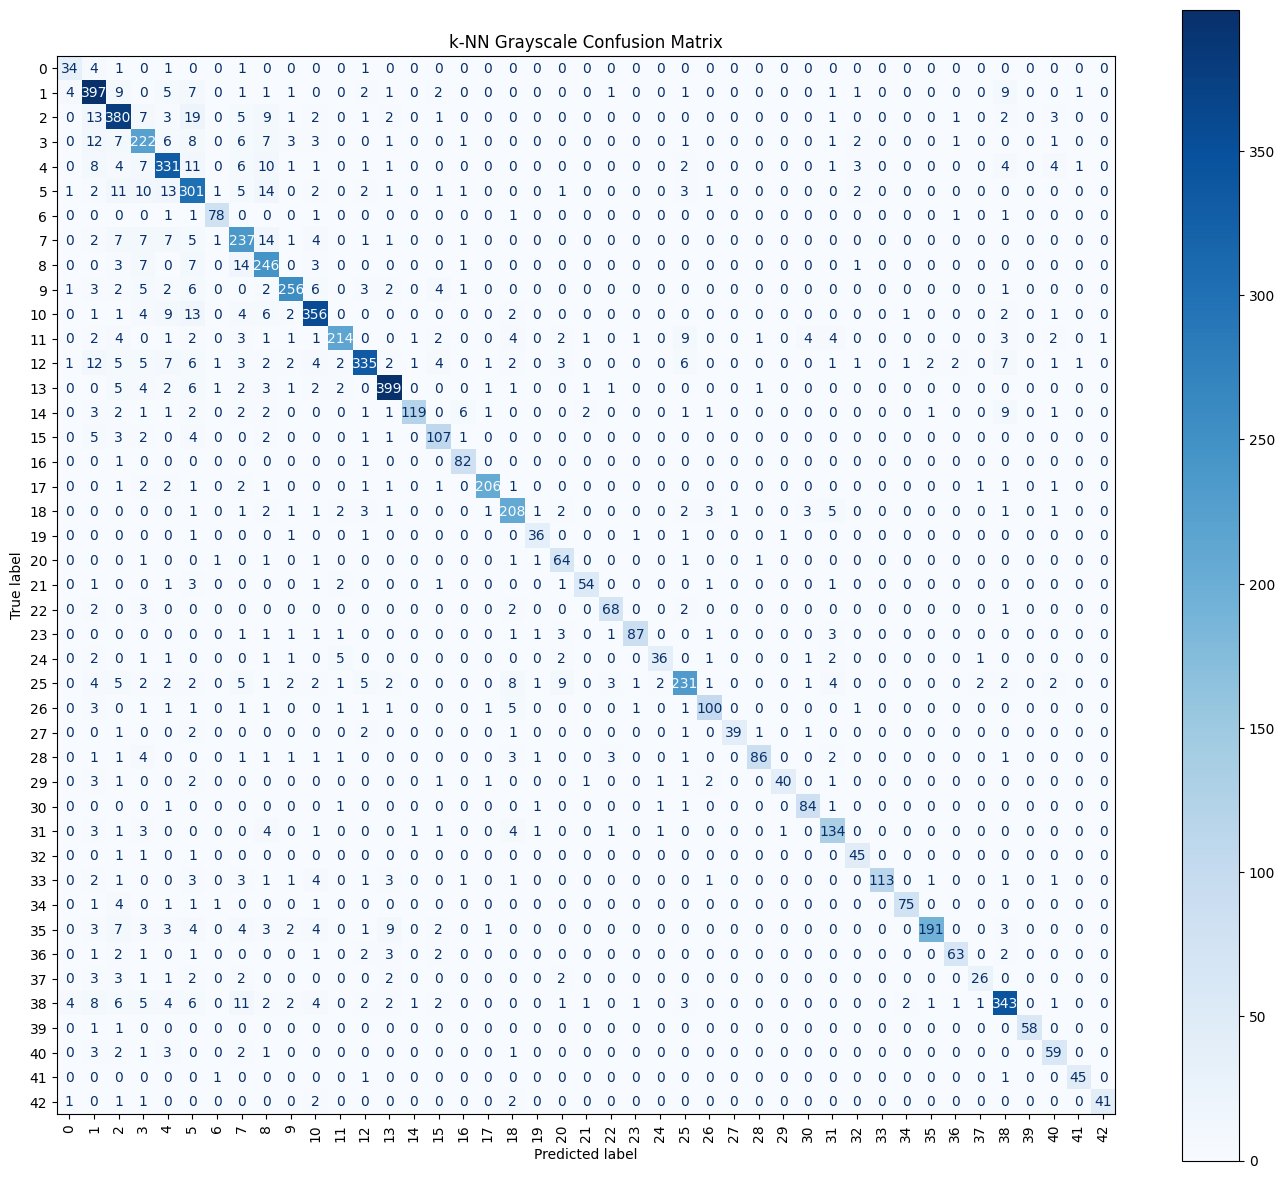

In [10]:
print("===== Matrix =====")
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", values_format="d")
plt.title("k-NN Grayscale Confusion Matrix")
plt.tight_layout()
plt.savefig("knn_gray_confusion_matrix.png", bbox_inches="tight")
plt.show()

Post Optimization K-nn (RGB k=5)

In [12]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [19]:
IMG_SIZE = 32
N_NEIGHBORS = 5
TEST_SIZE = 0.2
RANDOM_STATE = 42

CSV_PATH = os.path.join("archive", "Train.csv")
BASE_DIR = "archive"

In [20]:
print("===== Loading Report =====")

train_df = pd.read_csv(CSV_PATH)
train_df.head()

===== Loading Report =====


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [21]:
X = []
y = []
skipped = 0

for i in range(len(train_df)):
    relative_path = train_df.loc[i, "Path"]
    label = train_df.loc[i, "ClassId"]
    img_path = os.path.join(BASE_DIR, relative_path)

    img = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    X.append(img)
    y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print(f"Dataset loaded successfully")
print(f"Total images: {len(X)}")
print(f"Skipped images: {skipped}")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded successfully
Total images: 39209
Skipped images: 0
X shape: (39209, 32, 32, 3)
y shape: (39209,)


In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (31367, 32, 32, 3)
Validation shape: (7842, 32, 32, 3)


In [23]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_val_flat shape:", X_val_flat.shape)

X_train_flat shape: (31367, 3072)
X_val_flat shape: (7842, 3072)


In [24]:
knn = KNeighborsClassifier(n_neighbors=N_NEIGHBORS)
knn.fit(X_train_flat, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [25]:
train_pred = knn.predict(X_train_flat)
train_acc = accuracy_score(y_train, train_pred)

y_pred = knn.predict(X_val_flat)
val_acc = accuracy_score(y_val, y_pred)

print("\n===== Summary =====")
results_df = pd.DataFrame({
    "Train": [train_acc],
    "Val": [val_acc]
}, index=["k-NN RGB"])

display(results_df)


===== Summary =====


,Train,Val
k-NN RGB,0.922626,0.874777


In [26]:
print("Classification Report:\n")
print(classification_report(y_val, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.79      0.73        42
           1       0.83      0.93      0.88       444
           2       0.86      0.89      0.87       450
           3       0.74      0.80      0.77       282
           4       0.84      0.84      0.84       396
           5       0.73      0.85      0.78       372
           6       0.92      0.93      0.92        84
           7       0.75      0.85      0.80       288
           8       0.78      0.89      0.83       282
           9       0.94      0.88      0.91       294
          10       0.89      0.89      0.89       402
          11       0.93      0.81      0.87       264
          12       0.98      0.87      0.92       420
          13       0.95      0.93      0.94       432
          14       0.98      0.83      0.90       156
          15       0.86      0.85      0.85       126
          16       0.89      0.98      0.93        84
   

===== Matrix =====


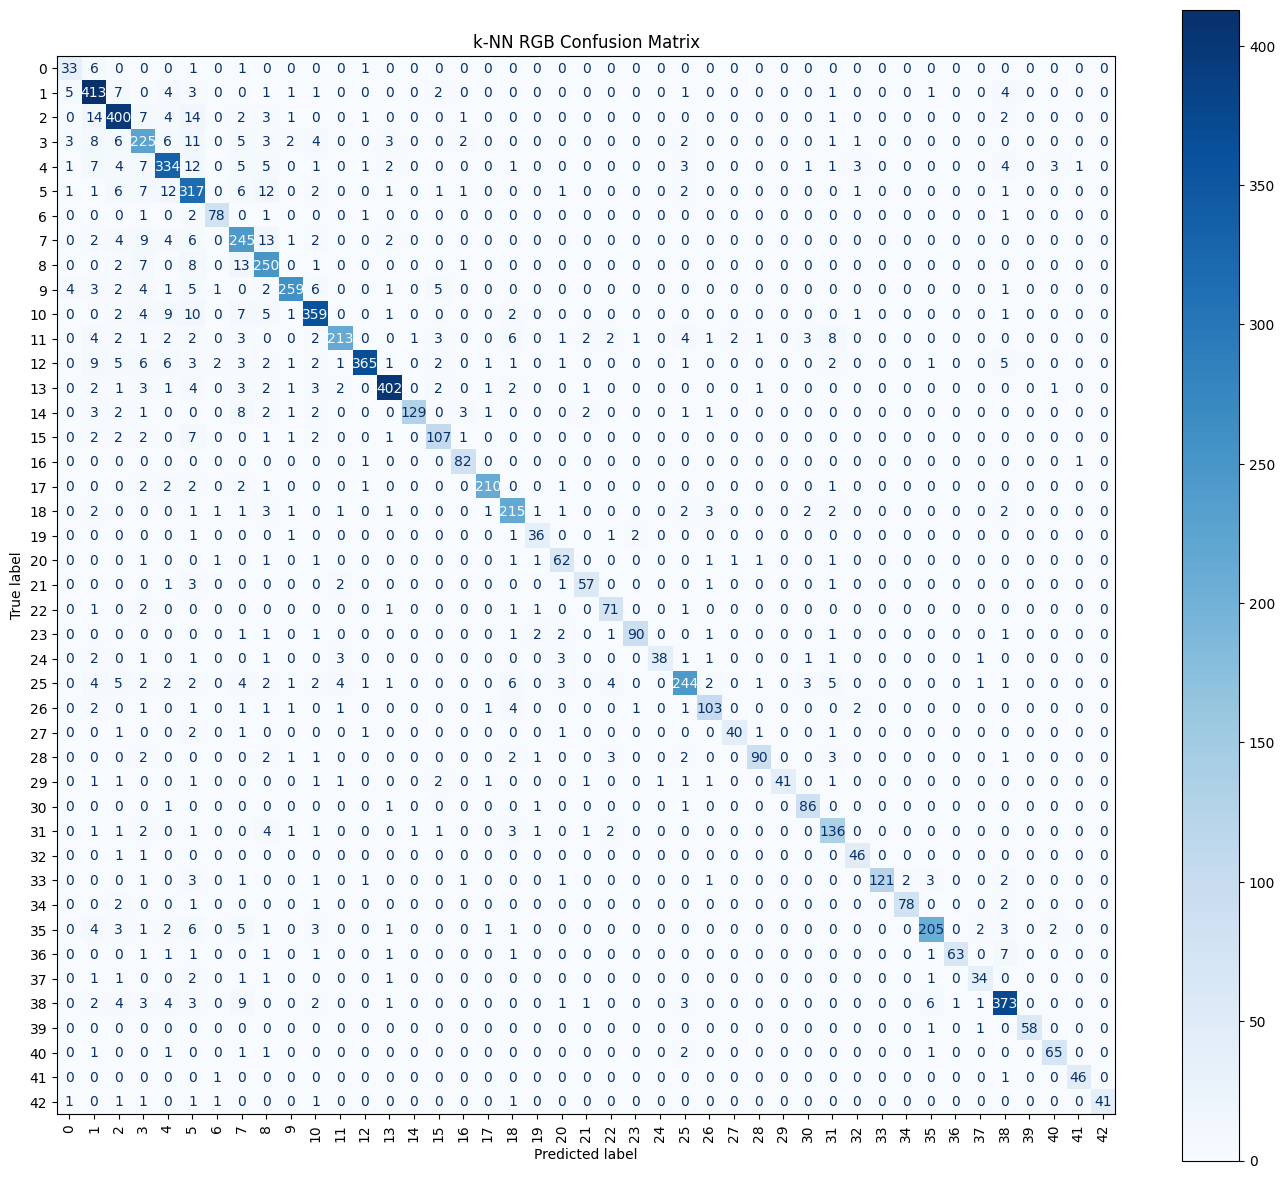

In [27]:
print("===== Matrix =====")
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", values_format="d")
plt.title("k-NN RGB Confusion Matrix")
plt.tight_layout()
plt.savefig("knn_rgb_confusion_matrix.png", bbox_inches="tight")
plt.show()

First tester Model | The Random Forest Models (gray more optimal than rgb)

Gray Scale:

In [29]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [30]:
IMG_SIZE = 32
N_ESTIMATORS = 200
TEST_SIZE = 0.2
RANDOM_STATE = 42

CSV_PATH = os.path.join("archive", "Train.csv")
BASE_DIR = "archive"

In [31]:
print("===== Loading Report =====")

train_df = pd.read_csv(CSV_PATH)
train_df.head()

===== Loading Report =====


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [32]:
X = []
y = []
skipped = 0

for i in range(len(train_df)):
    relative_path = train_df.loc[i, "Path"]
    label = train_df.loc[i, "ClassId"]
    img_path = os.path.join(BASE_DIR, relative_path)

    img = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    X.append(img)
    y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Dataset loaded successfully")
print(f"Total images: {len(X)}")
print(f"Skipped images: {skipped}")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded successfully
Total images: 39209
Skipped images: 0
X shape: (39209, 32, 32)
y shape: (39209,)


In [33]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (31367, 32, 32)
Validation shape: (7842, 32, 32)


In [34]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_val_flat shape:", X_val_flat.shape)

X_train_flat shape: (31367, 1024)
X_val_flat shape: (7842, 1024)


In [35]:
rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train_flat, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [36]:
train_pred = rf.predict(X_train_flat)
train_acc = accuracy_score(y_train, train_pred)

y_pred = rf.predict(X_val_flat)
val_acc = accuracy_score(y_val, y_pred)

print("\n===== Summary =====")
results_df = pd.DataFrame({
    "Train": [train_acc],
    "Val": [val_acc]
}, index=["RF Gray"])

display(results_df)


===== Summary =====


,Train,Val
RF Gray,1.0,0.977174


In [37]:
print("Classification Report:\n")
print(classification_report(y_val, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.74      0.85        42
           1       0.92      0.98      0.95       444
           2       0.95      0.96      0.95       450
           3       0.98      0.93      0.95       282
           4       0.97      0.97      0.97       396
           5       0.97      0.95      0.96       372
           6       0.99      1.00      0.99        84
           7       0.97      0.96      0.97       288
           8       0.94      0.98      0.96       282
           9       0.99      1.00      0.99       294
          10       0.99      1.00      0.99       402
          11       0.98      0.98      0.98       264
          12       0.96      1.00      0.98       420
          13       0.99      1.00      0.99       432
          14       1.00      1.00      1.00       156
          15       1.00      0.98      0.99       126
          16       1.00      0.99      0.99        84
   

===== Matrix =====


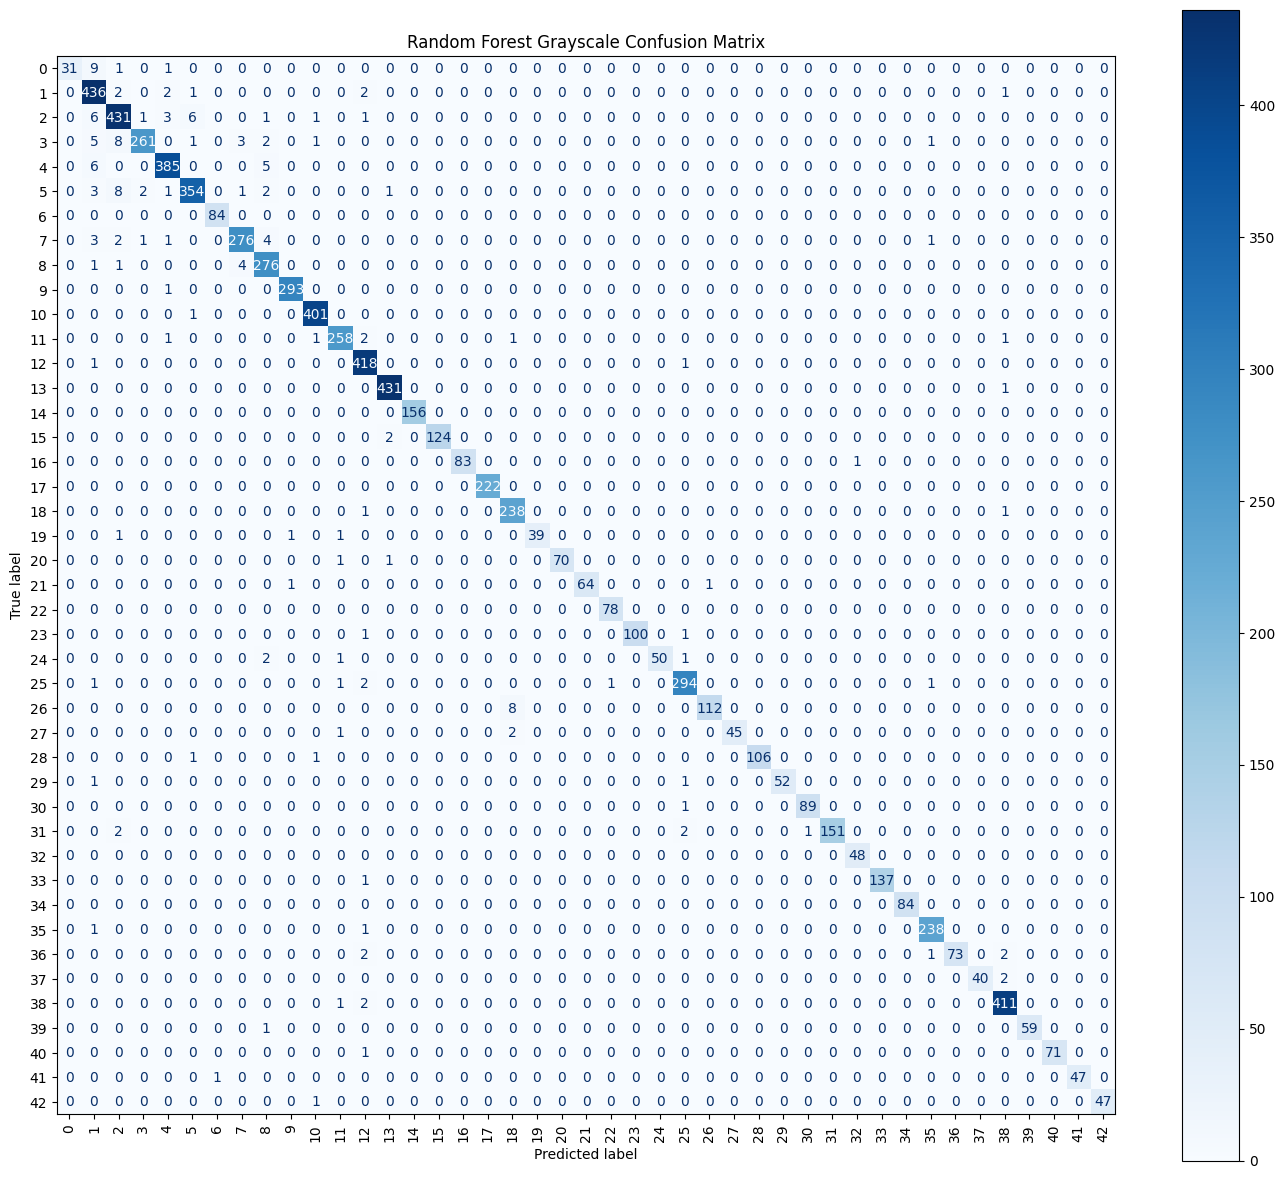

In [38]:
print("===== Matrix =====")
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", values_format="d")
plt.title("Random Forest Grayscale Confusion Matrix")
plt.tight_layout()
plt.savefig("rf_gray_confusion_matrix.png", bbox_inches="tight")
plt.show()

RGB:

In [39]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [40]:
IMG_SIZE = 32
N_ESTIMATORS = 200
TEST_SIZE = 0.2
RANDOM_STATE = 42

CSV_PATH = os.path.join("archive", "Train.csv")
BASE_DIR = "archive"

In [41]:
print("===== Loading Report =====")

train_df = pd.read_csv(CSV_PATH)
train_df.head()

===== Loading Report =====


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [42]:
X = []
y = []
skipped = 0

for i in range(len(train_df)):
    relative_path = train_df.loc[i, "Path"]
    label = train_df.loc[i, "ClassId"]
    img_path = os.path.join(BASE_DIR, relative_path)

    img = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    X.append(img)
    y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Dataset loaded successfully")
print(f"Total images: {len(X)}")
print(f"Skipped images: {skipped}")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded successfully
Total images: 39209
Skipped images: 0
X shape: (39209, 32, 32, 3)
y shape: (39209,)


In [43]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (31367, 32, 32, 3)
Validation shape: (7842, 32, 32, 3)


In [44]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_val_flat shape:", X_val_flat.shape)

X_train_flat shape: (31367, 3072)
X_val_flat shape: (7842, 3072)


In [45]:
rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train_flat, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [46]:
train_pred = rf.predict(X_train_flat)
train_acc = accuracy_score(y_train, train_pred)

y_pred = rf.predict(X_val_flat)
val_acc = accuracy_score(y_val, y_pred)

print("\n===== Summary =====")
results_df = pd.DataFrame({
    "Train": [train_acc],
    "Val": [val_acc]
}, index=["RF RGB"])

display(results_df)


===== Summary =====


,Train,Val
RF RGB,0.999745,0.973476


===== Matrix =====


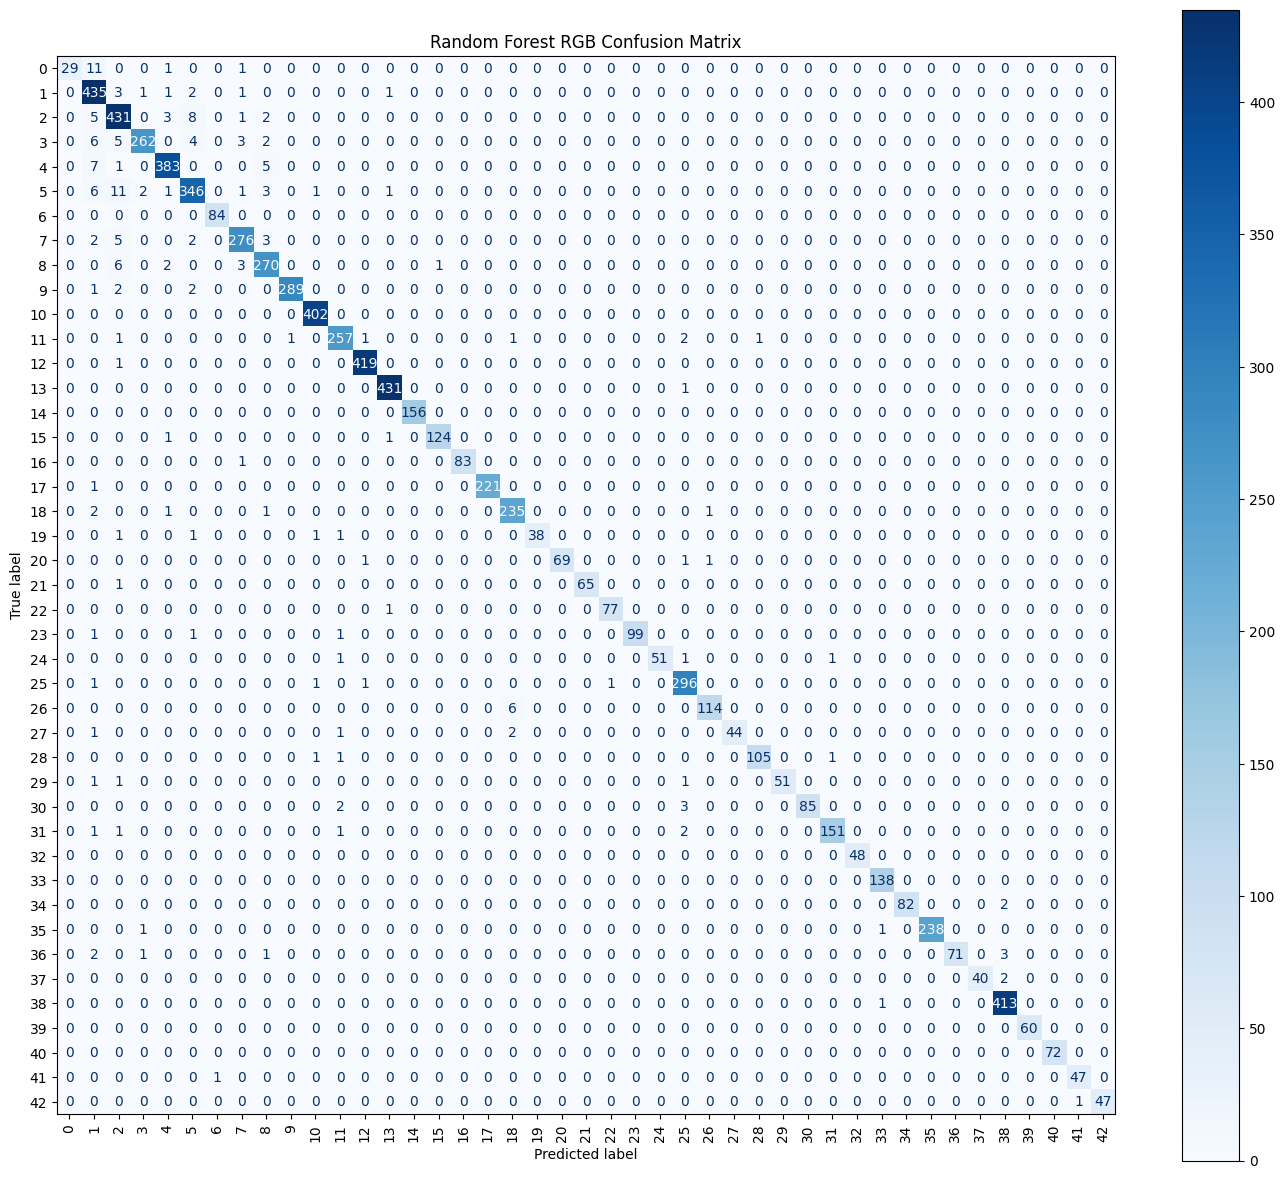

In [47]:
print("===== Matrix =====")
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", values_format="d")
plt.title("Random Forest RGB Confusion Matrix")
plt.tight_layout()
plt.savefig("rf_rgb_confusion_matrix.png", bbox_inches="tight")
plt.show()

Model 2 | Hog + linear SVC

In [48]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [49]:
IMG_SIZE = (32, 32)
RANDOM_STATE = 42

TRAIN_CSV_PATH = os.path.join("archive", "Train.csv")
TEST_CSV_PATH = os.path.join("archive", "Test.csv")
BASE_DIR = "archive"

In [50]:
print("===== Loading Report =====")

train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

train_df.head()

===== Loading Report =====


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [51]:
X_train = []
y_train = []
train_skipped = 0

print("\nExtracting HOG features from training set...")

for i in range(len(train_df)):
    relative_path = train_df.loc[i, "Path"]
    label = train_df.loc[i, "ClassId"]
    img_path = os.path.join(BASE_DIR, relative_path)

    if not os.path.exists(img_path):
        train_skipped += 1
        continue

    img = Image.open(img_path).convert("L")
    img = img.resize(IMG_SIZE)
    img_np = np.array(img)

    features = hog(
        img_np,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True
    )

    X_train.append(features)
    y_train.append(label)

    if (i + 1) % 5000 == 0 or (i + 1) == len(train_df):
        print(f"Processed {i + 1}/{len(train_df)} training images")

X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train)


Extracting HOG features from training set...
Processed 5000/39209 training images
Processed 10000/39209 training images
Processed 15000/39209 training images
Processed 20000/39209 training images
Processed 25000/39209 training images
Processed 30000/39209 training images
Processed 35000/39209 training images
Processed 39209/39209 training images


In [52]:
X_test = []
y_test = []
test_skipped = 0

print("\nExtracting HOG features from test set...")

for i in range(len(test_df)):
    relative_path = test_df.loc[i, "Path"]
    label = test_df.loc[i, "ClassId"]
    img_path = os.path.join(BASE_DIR, relative_path)

    if not os.path.exists(img_path):
        test_skipped += 1
        continue

    img = Image.open(img_path).convert("L")
    img = img.resize(IMG_SIZE)
    img_np = np.array(img)

    features = hog(
        img_np,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True
    )

    X_test.append(features)
    y_test.append(label)

    if (i + 1) % 5000 == 0 or (i + 1) == len(test_df):
        print(f"Processed {i + 1}/{len(test_df)} test images")

X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test)


Extracting HOG features from test set...
Processed 5000/12630 test images
Processed 10000/12630 test images
Processed 12630/12630 test images


In [53]:
print("\nDataset loaded successfully")
print(f"Total training images: {len(X_train)}")
print(f"Skipped training images: {train_skipped}")
print(f"Total test images: {len(X_test)}")
print(f"Skipped test images: {test_skipped}")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Dataset loaded successfully
Total training images: 39209
Skipped training images: 0
Total test images: 12630
Skipped test images: 0
Train shape: (39209, 1764)
Test shape: (12630, 1764)


In [54]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(
        C=0.1,
        max_iter=3000,
        tol=1e-3,
        random_state=RANDOM_STATE
    ))
])

In [55]:
start_train = time.time()
model.fit(X_train, y_train)
end_train = time.time()

print(f"Training time: {end_train - start_train:.2f} seconds")

Training time: 286.86 seconds


In [56]:
train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

results_df = pd.DataFrame({
    "Train": [train_acc],
    "Test": [test_acc]
}, index=["HOG + LinearSVC"])

print("\n===== Summary =====")
display(results_df)


===== Summary =====


,Train,Test
HOG + LinearSVC,0.999184,0.887569


In [57]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))


Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.52      0.57        60
           1       0.85      0.83      0.84       720
           2       0.79      0.82      0.81       750
           3       0.80      0.75      0.78       450
           4       0.92      0.92      0.92       660
           5       0.72      0.73      0.72       630
           6       0.84      0.81      0.83       150
           7       0.86      0.88      0.87       450
           8       0.81      0.80      0.80       450
           9       0.91      0.97      0.94       480
          10       0.95      0.95      0.95       660
          11       0.89      0.85      0.87       420
          12       0.98      0.98      0.98       690
          13       0.98      0.99      0.99       720
          14       0.94      0.93      0.93       270
          15       0.98      0.99      0.99       210
          16       0.95      0.97      0.96       150
  

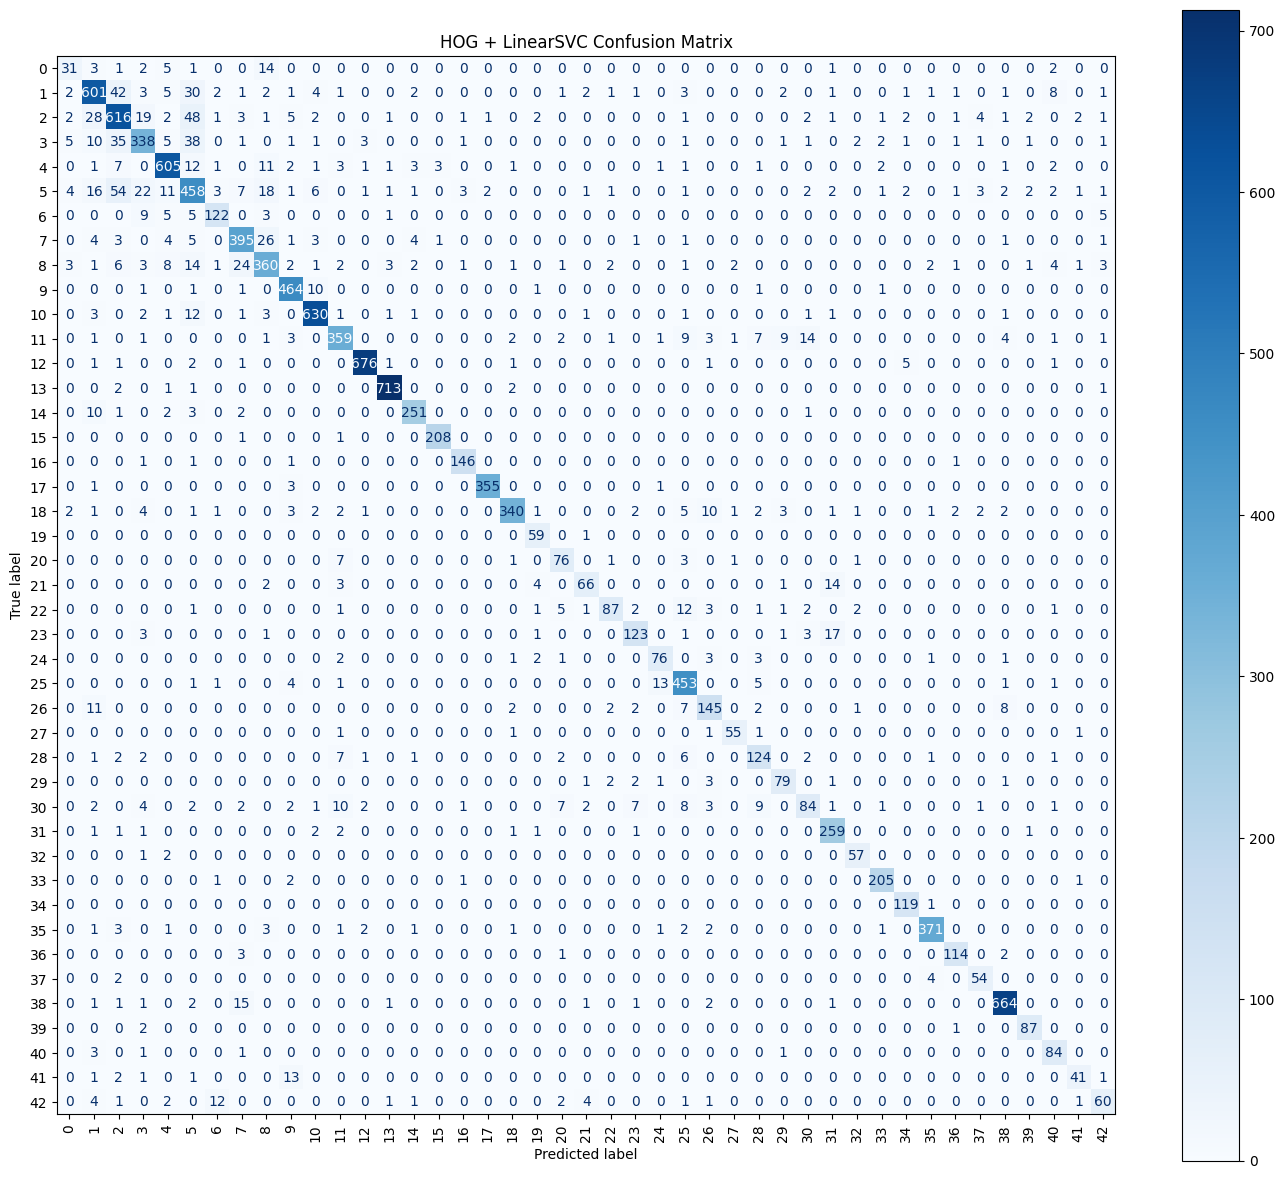

In [58]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", values_format="d")
plt.title("HOG + LinearSVC Confusion Matrix")
plt.tight_layout()
plt.show()